In [1]:
import pandas as pd
import numpy as np
import torch
from deepod.models.time_series import TcnED
from sklearn.metrics import f1_score, classification_report
from utils.data_loader import load_volvo, load_optuna_val
from utils.evaluation import cross_validate
from utils.hyperparameter_search import run_optuna_study
from utils.evaluation import evaluate_model

result_path="../Results/Volvo TcnED"

D:\Programming things\Examensarbete\Examensarbete 2.0\Exjobb-Gitrepo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train, y_train, X_test, y_test, timestamps_train, timestamps_test, df_train, df_test = load_volvo(
    "../Dataset/volvoTrain.csv",
    "../Dataset/volvoTest.csv"
)

In [3]:
print(torch.cuda.is_available())

True


### Optuna HPO

In [4]:
hyperparameters = {
    "lr": ("categorical", [1e-6, 1e-8, 1e-10]),
    "epochs": ("int", 5, 20, False),
    "rep_dim": ("int", 16, 64, False),
}

df_train_optuna = load_optuna_val(df_train)

study = run_optuna_study(
    model_class=TcnED,
    hyperparameters=hyperparameters,
    train_df=df_train_optuna,
    validation_ratio=0.20,
    n_trials=10,
    study_name="FinalTcnED_optuna__study",
    storage="sqlite:///FinalTcnEStudy_optuna.db"
)

print("Best params:", study.best_params)
print("Best validation score:", study.best_value)
print("Best trial extra metrics:", study.best_trial.user_attrs)

Best params: {'lr': 1e-10, 'epochs': 14, 'rep_dim': 50}
Best validation score: 0.1593466120717622
Best trial extra metrics: {'pr_auc': 0.1593466120717622}


In [5]:
best_params = study.best_params
static_params = {
    "seq_len": 50,
    "stride": 5,
    "device": 'cuda'
}

params = best_params | static_params

### Training w. hpo parameters

In [6]:
model = TcnED(**params)
model.fit(X_train)

scores_test = model.decision_function(X_test)
df_test["anomaly_score"] = scores_test

### Threshold calculation

In [7]:
cross_val_scores = cross_validate(train_df=df_train, model=TcnED, params=params, result_path=result_path)
print(cross_val_scores)

{'fold1_roc_auc': 0.6511236283359736, 'fold1_pr_auc': 0.00965217647228711, 'fold2_roc_auc': 0.6157569222861508, 'fold2_pr_auc': 0.10331949074804411, 'mean_threshold': 79.19700469970704}


### F1 calculation / evaluation of model

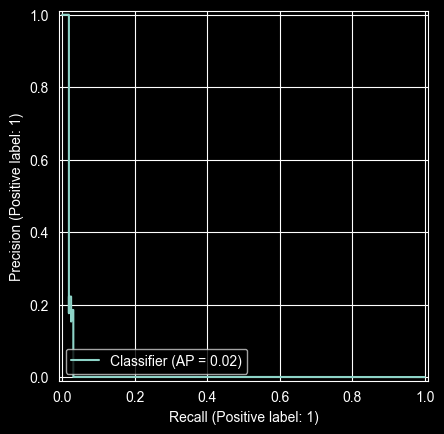

In [8]:
threshold = cross_val_scores["mean_threshold"]
evaluate_model(y_test, scores_test, threshold=threshold, result_path=result_path)

In [9]:
import pandas as pd
import os
df = pd.DataFrame(scores_test, columns=["score"])
scores_path = os.path.join(result_path, "scores.csv")
df.to_csv(scores_path, index = False)